In [2]:
%matplotlib inline
import json
import os
from datetime import datetime, timedelta
import pyarrow as pa
import pyarrow.parquet as pq
import scrython
from scrython.base import ScrythonRequestHandler
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

app_name = "EDHDataAnalysis"
app_email = "avivg2001@gmail.com"
path_cards_file = "cards.json"
path_cards_parquet = "cards.parquet"
path_scryfall_fields = "scryfall_fields.json"

## Fetch Data

In [2]:
def fetch_cards() -> pd.DataFrame:
    ScrythonRequestHandler.set_user_agent(f'{app_name}/1.0 ({app_email})')
    bulk = scrython.bulk_data.ByType(type='oracle_cards')
    bulk.download(filepath=path_cards_file, progress=True)

    df = clean_cards_df(pd.read_json(path_cards_file))
    table = pa.Table.from_pandas(df)
    merged_meta = {
        **(table.schema.metadata or {}),
        b'fetch_date': datetime.now().isoformat().encode(),
    }
    pq.write_table(table.replace_schema_metadata(merged_meta), path_cards_parquet)

    with open(path_scryfall_fields, 'w') as f:
        json.dump(list(df.columns), f, indent=2)

    return df

## Preprocess Data

In [29]:
WUBRG_ORDER = {c: i for i, c in enumerate('WUBRG')}

def clean_cards_df(df: pd.DataFrame) -> pd.DataFrame:
    scryfall_set_field_types(df)
    scryfall_filter_out_rows(df)

    return df

def scryfall_set_field_types(df: pd.DataFrame) -> pd.DataFrame:
    df['released_at'] = pd.to_datetime(df['released_at'], errors='coerce')

    # power/toughness can be "*" or "1+*" — coerce non-numeric to NaN
    numeric_cols = [
        'power', 'toughness', 'cmc', 'edhrec_rank', 'collector_number',
        'mtgo_id', 'mtgo_foil_id', 'tcgplayer_id', 'cardmarket_id',
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    if 'prices' in df.columns:
        prices = pd.json_normalize(df['prices'].tolist())
        prices.index = df.index
        for col in prices.columns:
            df[f'price_{col}'] = pd.to_numeric(prices[col], errors='coerce')
        df = df.drop(columns=['prices'])

    if 'legalities' in df.columns:
        legalities = pd.json_normalize(df['legalities'].tolist())
        legalities.index = df.index
        for col in legalities.columns:
            df[f'legal_{col}'] = legalities[col] == 'legal'
        df = df.drop(columns=['legalities'])

    _wubrg_sort = lambda c: sorted(c, key=lambda x: WUBRG_ORDER.get(x, 99))
    for col in ('color_identity', 'colors'):
        if col in df.columns:
            df[col] = df[col].map(_wubrg_sort, na_action='ignore')

    categorical_cols = ['rarity', 'layout', 'set_type', 'border_color', 'frame', 'lang', 'image_status']
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    bool_cols = [
        'reserved', 'game_changer', 'foil', 'nonfoil', 'oversized', 'promo',
        'reprint', 'variation', 'digital', 'full_art', 'textless', 'booster',
        'story_spotlight', 'highres_image',
    ]
    for col in bool_cols:
        if col in df.columns:
            df[col] = df[col].astype('boolean')

    return df

def scryfall_filter_out_rows(df: pd.DataFrame) -> pd.DataFrame:
    if 'legal_commander' in df.columns and 'games' in df.columns:
        df = df[df['legal_commander'] & df['games'].apply(lambda x: 'paper' in x)]

    return df

def _expected_parquet_columns() -> frozenset | None:
    if not os.path.exists(path_scryfall_fields):
        return None
    with open(path_scryfall_fields) as f:
        return frozenset(json.load(f))

## Load Dataframe

In [30]:
def load_cards_df() -> pd.DataFrame:
    fetch_date = None
    schema_ok = False

    if os.path.exists(path_cards_parquet):
        parquet_cols = frozenset(pq.read_schema(path_cards_parquet).names)
        schema_ok = parquet_cols == _expected_parquet_columns()
        meta = pq.read_metadata(path_cards_parquet).metadata or {}
        fetch_date_str = meta.get(b'fetch_date', b'').decode()
        if fetch_date_str:
            fetch_date = datetime.fromisoformat(fetch_date_str)

    stale = fetch_date is None or (datetime.now() - fetch_date) >= timedelta(weeks=2)

    if schema_ok and not stale:
        return pd.read_parquet(path_cards_parquet)

    return fetch_cards()

cards_df = load_cards_df()

# One-time: re-save parquet with WUBRG-sorted color_identity and colors
_wubrg_sort = lambda c: sorted(c, key=lambda x: WUBRG_ORDER.get(x, 99))
for _col in ('color_identity', 'colors'):
    if _col in cards_df.columns:
        cards_df[_col] = cards_df[_col].map(_wubrg_sort, na_action='ignore')
table = pa.Table.from_pandas(cards_df)
meta = pq.read_metadata(path_cards_parquet).metadata or {}
pq.write_table(table.replace_schema_metadata(meta), path_cards_parquet)

# Data Validation

## Overview

In [ ]:
OVERVIEW_COLS = [
    'name', 'cmc', 'color_identity', 'mana_cost', 'type_line', 'set',
    'oracle_text', 'power', 'toughness', 'edhrec_rank', 'produced_mana',
    'game_changer', 'price_usd', 'legal_commander',
]

def print_df_stats(df: pd.DataFrame) -> None:
    print(f"Cards: {len(df):,}")
    print(f"Fields: {len(df.columns)}\n")

    cols = [c for c in OVERVIEW_COLS if c in df.columns]
    col_width = max(len(c) for c in cols)
    for col in cols:
        dtype = str(df[col].dtype)
        null_pct = df[col].isna().mean() * 100
        filled_pct = 100 - null_pct
        print(f"  {col:<{col_width}}  {dtype:<12}  {filled_pct:5.1f}% filled")
    
print_df_stats(cards_df)

In [ ]:
def print_top_edhrec(df: pd.DataFrame, n: int = 10) -> None:
    top = (df.dropna(subset=['edhrec_rank'])
             .sort_values('edhrec_rank')
             .head(n)[['name', 'edhrec_rank', 'type_line', 'cmc']])
    print(top.to_string(index=False))

print_top_edhrec(cards_df)

## CMC Distribution

In [ ]:
def plot_cmc_distribution(df: pd.DataFrame, n: int = 1000) -> None:
    top = (df.dropna(subset=['edhrec_rank', 'cmc'])
             .sort_values('edhrec_rank'))
    top['cmc'].value_counts().sort_index().plot(kind='bar')
    plt.title(f'CMC Distribution — Top {n} EDHREC Cards')
    plt.xlabel('CMC')
    plt.ylabel('Card Count')
    plt.tight_layout()
    plt.show()

In [ ]:
plot_cmc_distribution(cards_df)

## Color Identity Distribution

In [ ]:
def plot_color_identity_distribution(df: pd.DataFrame) -> None:
    color_names = {'W': 'White', 'U': 'Blue', 'B': 'Black', 'R': 'Red', 'G': 'Green'}

    def categorize(colors):
        if len(colors) == 0:
            return 'Colorless'
        if len(colors) == 1:
            return color_names[colors[0]]
        return 'Multicolored'

    order = ['White', 'Blue', 'Black', 'Red', 'Green', 'Colorless', 'Multicolored']
    counts = df['color_identity'].apply(categorize).value_counts().reindex(order, fill_value=0)
    counts.plot(kind='bar')
    plt.title('Card Count by Color Identity')
    plt.xlabel('Color')
    plt.ylabel('Card Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
plot_color_identity_distribution(cards_df)

## Card Count by Year

In [5]:
def plot_card_count_by_year(df: pd.DataFrame) -> None:
    year_counts = (
        df.dropna(subset=['released_at'])
          .assign(year=lambda d: d['released_at'].dt.year)
          .groupby('year')
          .size()
          .reset_index(name='count')
    )
    plt.figure(figsize=(12, 5))
    plt.bar(year_counts['year'], year_counts['count'])
    plt.title('Card Count by Year')
    plt.xlabel('Year')
    plt.ylabel('Card Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

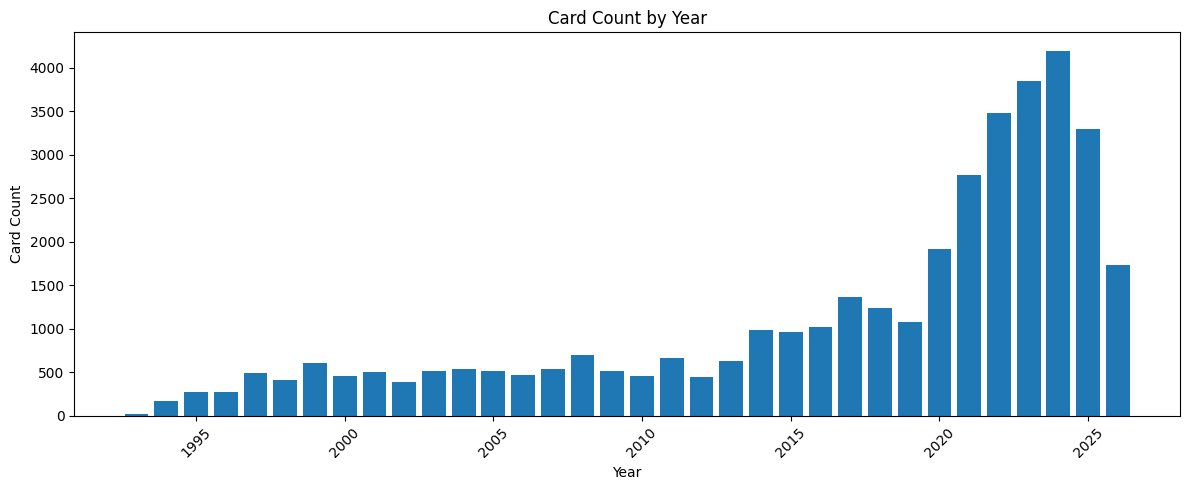

In [6]:
plot_card_count_by_year(cards_df)

# Outliers

## Field Statistics

For each field: mean, std, median, and the 5 highest/lowest cards (subsorted by EDHREC rank).

In [15]:
def print_field_outliers(df: pd.DataFrame, value_col: str, label: str,
                          name_col: str = 'name', rank_col: str = 'edhrec_rank', n: int = 5) -> None:
    s = df.dropna(subset=[value_col, name_col]).copy()

    print(f"{'=' * 55}")
    print(f"  {label}")
    print(f"{'=' * 55}")
    print(f"  Count:  {len(s):,}")
    print(f"  Mean:   {s[value_col].mean():.2f}")
    print(f"  Std:    {s[value_col].std():.2f}")
    print(f"  Median: {s[value_col].median():.2f}")

    # Sort by value, use edhrec_rank as tie-breaker (NaN rank goes last)
    lowest  = s.sort_values([value_col, rank_col], ascending=[True,  True], na_position='last').head(n)
    highest = s.sort_values([value_col, rank_col], ascending=[False, True], na_position='last').head(n)

    display_cols = [name_col, value_col, rank_col]

    print(f"\n  Lowest {n}:")
    print(lowest[display_cols].to_string(index=False))

    print(f"\n  Highest {n}:")
    print(highest[display_cols].to_string(index=False))
    print()

### Name Length

In [16]:
_outlier_df = cards_df.copy()
_outlier_df['name_length'] = _outlier_df['name'].str.len()
_outlier_df['oracle_text_length'] = _outlier_df['oracle_text'].str.len()

print_field_outliers(_outlier_df, 'name_length', 'Name Length')

  Name Length
  Count:  37,442
  Mean:   17.82
  Std:    8.34
  Median: 16.00

  Lowest 5:
name  name_length  edhrec_rank
   X            1          NaN
  Ow            2          NaN
  Ox            2          NaN
  Ox            2          NaN
  Ox            2          NaN

  Highest 5:
                                                                                                                                         name  name_length  edhrec_rank
Our Market Research Shows That Players Like Really Long Card Names So We Made this Card to Have the Absolute Longest Card Name Ever Elemental          141          NaN
                                                                       Roaring Furnace // Steaming Sauna // Roaring Furnace // Steaming Sauna           70          NaN
                                                                         Baxter, Exzzperimental Zzientist // Baxter, Exzzperimental Zzientist           68          NaN
                                     

### CMC

In [17]:
print_field_outliers(_outlier_df, 'cmc', 'CMC (Converted Mana Cost)')

  CMC (Converted Mana Cost)
  Count:  37,442
  Mean:   29.64
  Std:    5167.96
  Median: 3.00

  Lowest 5:
            name  cmc  edhrec_rank
   Command Tower  0.0          2.0
  Exotic Orchard  0.0          9.0
 Reliquary Tower  0.0         10.0
Path of Ancestry  0.0         14.0
  Evolving Wilds  0.0         17.0

  Highest 5:
               name       cmc  edhrec_rank
            Gleemax 1000000.0          NaN
              Draco      16.0       9738.0
  Earthquake Dragon      15.0       3167.0
Shadow of Mortality      15.0       4368.0
    Autochthon Wurm      15.0      19578.0



### Power

In [18]:
print_field_outliers(_outlier_df, 'power', 'Power')

  Power
  Count:  18,898
  Mean:   2.67
  Std:    1.83
  Median: 2.00

  Lowest 5:
                name  power  edhrec_rank
     Spinal Parasite   -1.0      25786.0
        Char-Rumbler   -1.0      29127.0
Half-Squirrel, Half-   -1.0          NaN
   Birds of Paradise    0.0         33.0
        Blood Artist    0.0        140.0

  Highest 5:
                         name  power  edhrec_rank
   B.F.M. (Big Furry Monster)   99.0          NaN
Dawnsire, Sunstar Dreadnought   20.0       3511.0
                   Marit Lage   20.0          NaN
           Yargle and Multani   18.0       2919.0
         Impervious Greatwurm   16.0       4280.0



### Toughness

In [19]:
print_field_outliers(_outlier_df, 'toughness', 'Toughness')

  Toughness
  Count:  18,956
  Mean:   2.88
  Std:    1.85
  Median: 3.00

  Lowest 5:
               name  toughness  edhrec_rank
    Spinal Parasite       -1.0      25786.0
Phyrexian Metamorph        0.0        301.0
       Spark Double        0.0        404.0
   Walking Ballista        0.0        463.0
    Faeburrow Elder        0.0        518.0

  Highest 5:
                         name  toughness  edhrec_rank
   B.F.M. (Big Furry Monster)       99.0          NaN
      The Walls of Ba Sing Se       30.0       2710.0
Dawnsire, Sunstar Dreadnought       20.0       3511.0
          Ancient Adamantoise       20.0       5453.0
        Kharis & The Beholder       20.0          NaN



### Oracle Text Length

In [20]:
print_field_outliers(_outlier_df, 'oracle_text_length', 'Oracle Text Length')

  Oracle Text Length
  Count:  34,309
  Mean:   158.37
  Std:    92.11
  Median: 146.00

  Lowest 5:
                name  oracle_text_length  edhrec_rank
             Memnite                 0.0       2324.0
    Phyrexian Walker                 0.0       2898.0
  Yargle and Multani                 0.0       2919.0
       Gigantosaurus                 0.0       4656.0
Indomitable Ancients                 0.0       4792.0

  Highest 5:
                              name  oracle_text_length  edhrec_rank
          Baldur's Gate Wilderness              1489.0          NaN
                       Bureaucracy               774.0          NaN
                     Booster Blitz               763.0          NaN
           Dungeon of the Mad Mage               707.0          NaN
Shadows Over Innistrad Checklist 1               706.0          NaN



## Top 5 Oldest Cards

In [11]:
def print_oldest_cards(df: pd.DataFrame, n: int = 5) -> None:
    oldest = (df.dropna(subset=['released_at'])
                .sort_values('released_at')
                .head(n)[['name', 'released_at', 'set', 'type_line', 'edhrec_rank']])
    print(f"Top {n} Oldest Cards:")
    print(oldest.to_string(index=False))

print_oldest_cards(cards_df)

Top 5 Oldest Cards:
             name released_at  set   type_line  edhrec_rank
         Proposal  1993-11-01 pcel     Sorcery          NaN
Natural Selection  1993-12-01  2ed     Instant      27249.0
     Raging River  1993-12-01  2ed Enchantment      19997.0
     False Orders  1993-12-01  2ed     Instant      23411.0
       Camouflage  1993-12-01  2ed     Instant      25173.0


## Best EDHREC Rank per Color

In [31]:
def print_best_edhrec_per_color(df: pd.DataFrame) -> None:
    s = df.dropna(subset=['edhrec_rank', 'colors']).copy()

    # colors is already in WUBRG order from preprocessing — just join
    s['color_key'] = s['colors'].apply(
        lambda c: ''.join(c) if len(c) > 0 else 'C'
    )

    idx = s.groupby('color_key')['edhrec_rank'].idxmin()
    result = s.loc[idx][['color_key', 'name', 'edhrec_rank', 'type_line', 'cmc']].copy()

    def color_sort_key(key):
        if key == 'C':
            return (0, ())
        return (len(key), tuple(WUBRG_ORDER[c] for c in key))

    result = result.iloc[result['color_key'].map(color_sort_key).argsort()]

    print("Best EDHREC Rank (most popular) per Color:")
    print(result.to_string(index=False))

print_best_edhrec_per_color(cards_df)

Best EDHREC Rank (most popular) per Color:
color_key                      name  edhrec_rank                                   type_line  cmc
        C                  Sol Ring          1.0                                    Artifact  1.0
        W      Swords to Plowshares         11.0                                     Instant  1.0
        U              Counterspell         16.0                                     Instant  2.0
        B               Dark Ritual         34.0                                     Instant  1.0
        R           Blasphemous Act         23.0                                     Sorcery  9.0
        G                 Cultivate         20.0                                     Sorcery  3.0
       WU              Dovin's Veto        252.0                                     Instant  2.0
       WB        Anguished Unmaking        153.0                                     Instant  3.0
       WR               Boros Charm        174.0                           

## Highest Priced Card (USD) per Set

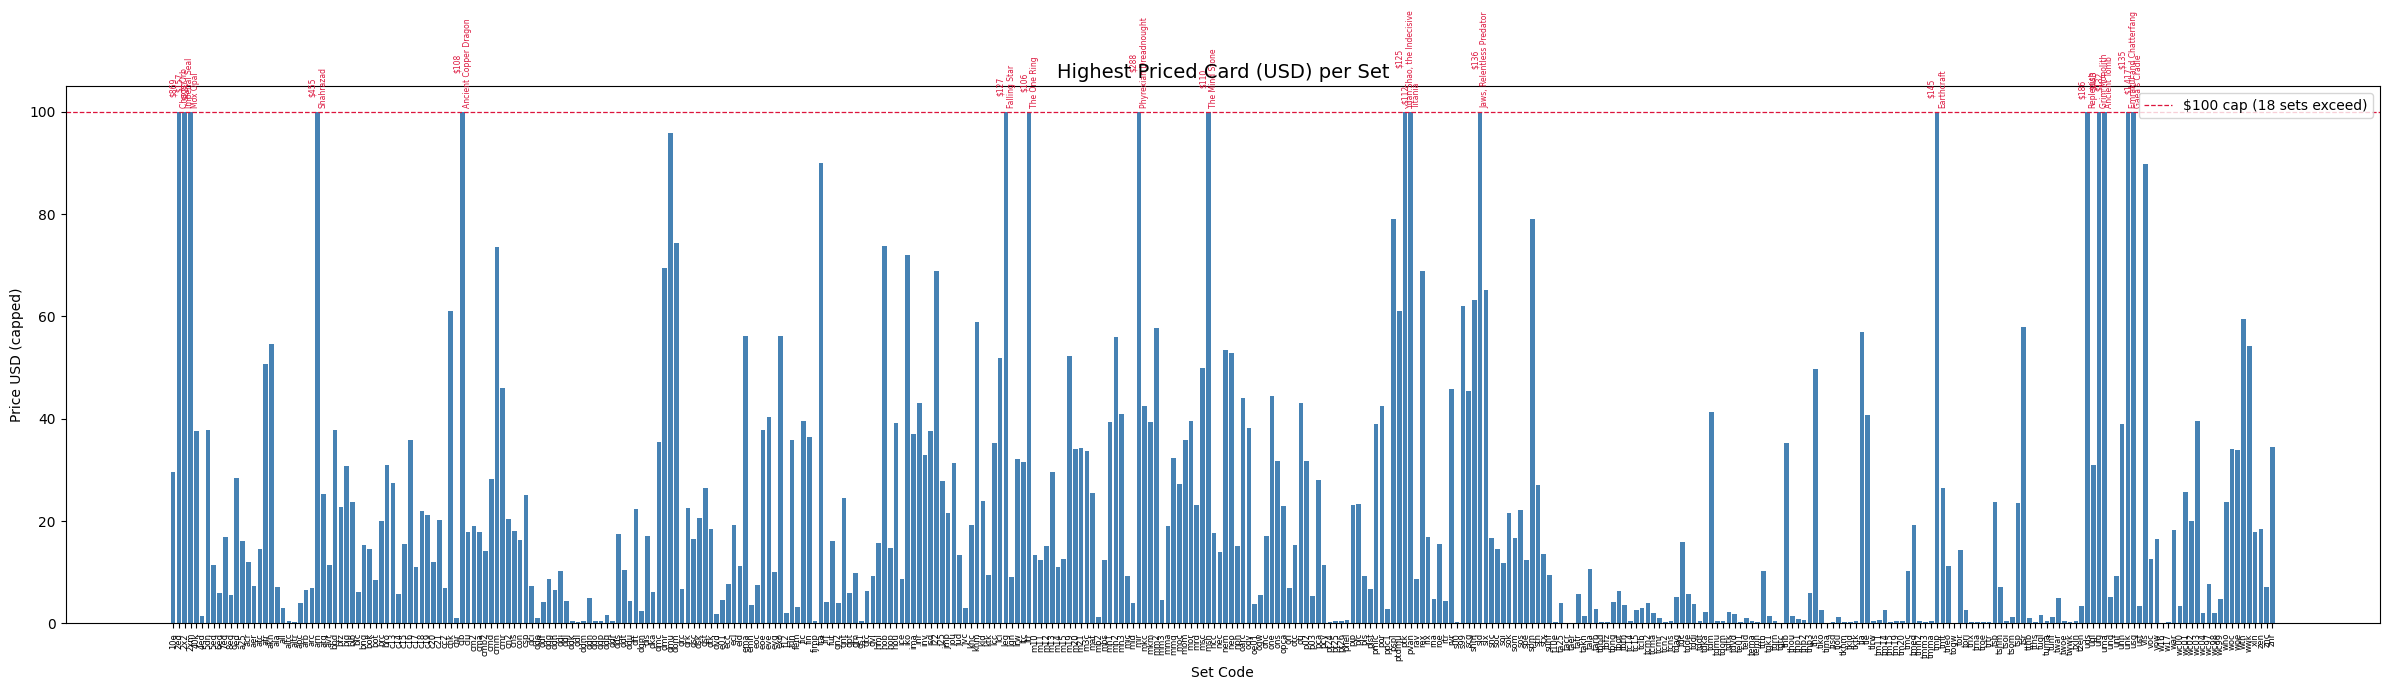

In [14]:
def plot_highest_price_per_set(df: pd.DataFrame, cap: float = 100.0) -> None:
    price_col = 'price_usd'
    s = df.dropna(subset=[price_col, 'set', 'name']).copy()

    # Highest priced card per set
    idx = s.groupby('set')[price_col].idxmax()
    top = (s.loc[idx][['set', 'set_name', 'name', price_col]]
             .sort_values('set')
             .reset_index(drop=True))

    capped_prices = top[price_col].clip(upper=cap)
    exceeds_mask  = top[price_col] > cap

    fig, ax = plt.subplots(figsize=(24, 7))
    bars = ax.bar(range(len(top)), capped_prices, color='steelblue', width=0.8)

    # Label bars that exceed the cap
    for i, row in top[exceeds_mask].iterrows():
        ax.text(
            i, cap + 0.8,
            f"${row[price_col]:,.0f}\n{row['name']}",
            ha='center', va='bottom', fontsize=5.5, rotation=90,
            color='crimson',
        )

    ax.axhline(y=cap, color='crimson', linestyle='--', linewidth=0.9,
               label=f'${cap:.0f} cap ({exceeds_mask.sum()} sets exceed)')
    ax.set_title('Highest Priced Card (USD) per Set', fontsize=14)
    ax.set_xlabel('Set Code')
    ax.set_ylabel('Price USD (capped)')
    ax.set_xticks(range(len(top)))
    ax.set_xticklabels(top['set'].values, rotation=90, fontsize=6)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_highest_price_per_set(cards_df)